**Notebook Objective**

The purpose of this notebook is to perform a detailed evaluation of the machine-learning models developed in 03_modeling.ipynb.

The modeling notebook compared Logistic Regression, Random Forest, and Gradient Boosting using accuracy, precision, recall, F1-score, and ROC-AUC.

Based on the initial model comparison, Logistic Regression was selected as the final model because it provided a strong overall balance of performance and produced stronger recall and F1-score than the other models. Although Gradient Boosting achieved a slightly higher ROC-AUC, Logistic Regression was selected because identifying customers who are at risk of churn is the primary business objective.

1. Import Libraries

In [44]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
     accuracy_score, 
     precision_score,
      recall_score, 
      f1_score, 
      roc_auc_score,
       confusion_matrix, 
       classification_report,
        roc_curve, 
        precision_recall_curve
        )

2. Load the Dataset

In [45]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [46]:
print(df.shape)

(7043, 21)


3. Reproduce Feature Engineering

3.1 Convert TotalCharges to Numeric

In [47]:
df["TotalCharges"] = pd.to_numeric( df["TotalCharges"], errors="coerce" )

3.2 Handle Missing TotalCharges

In [48]:
df = df.dropna( subset=["TotalCharges"] )

3.3 Separate Features and Target

In [49]:
X = df.drop( columns=["Churn"] )

y = df["Churn"].map({ "No": 0, "Yes": 1 })

3.4 Identify Feature Types

In [50]:
numerical_features = X.select_dtypes( include=["int64", "float64"] ).columns.tolist() 

categorical_features = X.select_dtypes( include=["object"] ).columns.tolist()

C:\Users\kedha\AppData\Local\Temp\ipykernel_12968\812576083.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes( include=["object"] ).columns.tolist()


3.5 Create Dummy Variables

In [51]:
X = pd.get_dummies( X, columns=categorical_features, drop_first=True, dtype=int )

3.6 Train/Test Split

In [52]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y )

3.7 Standardize Numerical Features

In [53]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler() 

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy() 

X_train_scaled[numerical_features] = scaler.fit_transform( X_train[numerical_features] ) 

X_test_scaled[numerical_features] = scaler.transform( X_test[numerical_features] )

4. Recreate the Three Models

4.1 Logistic Regression

In [54]:
logistic_model = LogisticRegression( max_iter=1000, random_state=42 )
logistic_model.fit( X_train_scaled, y_train )

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

4.2 Random Forest

In [55]:
random_forest_model = RandomForestClassifier( n_estimators=100, random_state=42 )
random_forest_model.fit( X_train_scaled, y_train )

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

4.3 Gradient Boosting

In [56]:
gradient_boosting_model = GradientBoostingClassifier( random_state=42 )
gradient_boosting_model.fit( X_train_scaled, y_train )

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

5. Generate Test Predictions

5.1 Logistic Regression

In [57]:
logistic_predictions = logistic_model.predict( X_test_scaled ) 
logistic_probabilities = logistic_model.predict_proba( X_test_scaled )[:, 1]

5.2 Random Forest

In [58]:
random_forest_predictions = random_forest_model.predict( X_test_scaled ) 
random_forest_probabilities = random_forest_model.predict_proba( X_test_scaled )[:, 1]

5.3 Gradient Boosting

In [59]:
gradient_boosting_predictions = gradient_boosting_model.predict( X_test_scaled ) 
gradient_boosting_probabilities = gradient_boosting_model.predict_proba( X_test_scaled )[:, 1]

6. Review Overall Model Performance

In [60]:
evaluation_results = pd.DataFrame({ "Model": [ "Logistic Regression", "Random Forest", "Gradient Boosting" ],
                                    "Accuracy": [ accuracy_score(y_test, logistic_predictions), accuracy_score(y_test, random_forest_predictions), accuracy_score(y_test, gradient_boosting_predictions) ], 
                                    "Precision": [ precision_score(y_test, logistic_predictions), precision_score(y_test, random_forest_predictions), precision_score(y_test, gradient_boosting_predictions) ],
                                      "Recall": [ recall_score(y_test, logistic_predictions), recall_score(y_test, random_forest_predictions), recall_score(y_test, gradient_boosting_predictions) ],
                                        "F1 Score": [ f1_score(y_test, logistic_predictions), f1_score(y_test, random_forest_predictions), f1_score(y_test, gradient_boosting_predictions) ],
                                          "ROC-AUC": [ roc_auc_score(y_test, logistic_probabilities), roc_auc_score(y_test, random_forest_probabilities), roc_auc_score(y_test, gradient_boosting_probabilities) ] }) 
evaluation_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8038,0.6494,0.5695,0.6068,0.8360
1,Random Forest,0.7946,0.6628,0.4626,0.5449,0.8257
2,Gradient Boosting,0.7946,0.6481,0.4973,0.5628,0.8409


7. Final Model Selection

Although Gradient Boosting achieved the highest ROC-AUC, Logistic Regression was selected as the final model because it provided a strong overall balance of classification performance and produced stronger recall and F1-score in the modeling stage.

For this project, recall is particularly relevant because a false negative represents a customer who actually churns but was not identified by the model as a potential churner.

The ability to interpret Logistic Regression coefficients also provides additional insight into which customer characteristics are associated with churn.

8. Final Model Performance

8.1 Logistic Regression Metrics

In [61]:
final_accuracy = accuracy_score( y_test, logistic_predictions )
final_precision = precision_score( y_test, logistic_predictions )
final_recall = recall_score( y_test, logistic_predictions )
final_f1 = f1_score( y_test, logistic_predictions )
final_roc_auc = roc_auc_score( y_test, logistic_probabilities )
print(f"Accuracy: {final_accuracy:.3f}")
print(f"Precision: {final_precision:.3f}")
print(f"Recall: {final_recall:.3f}")
print(f"F1 Score: {final_f1:.3f}")
print(f"ROC-AUC: {final_roc_auc:.3f}")

Accuracy: 0.804
Precision: 0.649
Recall: 0.570
F1 Score: 0.607
ROC-AUC: 0.836


9. Classification Report

In [62]:
print( classification_report( y_test, logistic_predictions, target_names=["No Churn", "Churn"] ) )

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



10. Confusion Matrix

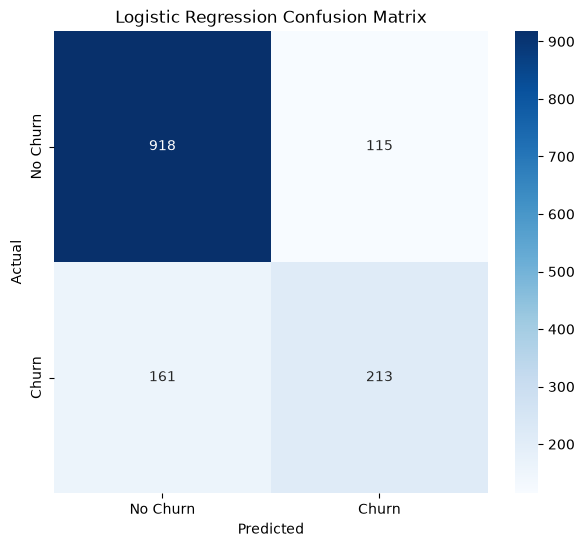

In [63]:
logistic_cm = confusion_matrix( y_test, logistic_predictions )
plt.figure(figsize=(7, 6)) 
sns.heatmap( logistic_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"] )
plt.title("Logistic Regression Confusion Matrix") 
plt.xlabel("Predicted") 
plt.ylabel("Actual") 
plt.show()

11. Interpret the Confusion Matrix

In [64]:
tn, fp, fn, tp = logistic_cm.ravel() 
print(f"True Negatives: {tn}") 
print(f"False Positives: {fp}") 
print(f"False Negatives: {fn}") 
print(f"True Positives: {tp}")

True Negatives: 918
False Positives: 115
False Negatives: 161
True Positives: 213


**Business Interpretation**

True Positive:
A customer who churned and was correctly identified by the model.

True Negative:
A customer who stayed and was correctly identified as unlikely to churn.

False Positive:
A customer who stayed but was incorrectly identified as likely to churn.

False Negative:
A customer who churned but was not identified by the model.

The false-negative group is particularly important because these are customers the business may have had an opportunity to retain but the model failed to identify.

12. Actual vs. Predicted Churn

In [65]:
prediction_results = pd.DataFrame({ "Actual_Churn": y_test.values, "Predicted_Churn": logistic_predictions, "Churn_Probability": logistic_probabilities }) 
prediction_results.head()

,Actual_Churn,Predicted_Churn,Churn_Probability
0,0,0,0.017867
1,0,1,0.592002
2,0,0,0.005146
3,1,0,0.193734
4,0,0,0.099974


12.1 Prediction Counts

In [66]:
prediction_comparison = pd.crosstab( prediction_results["Actual_Churn"], prediction_results["Predicted_Churn"], rownames=["Actual"], colnames=["Predicted"] ) 
prediction_comparison

Predicted,0,1
Actual,,
0,918,115
1,161,213


13. Visualize Actual vs. Predicted Churn

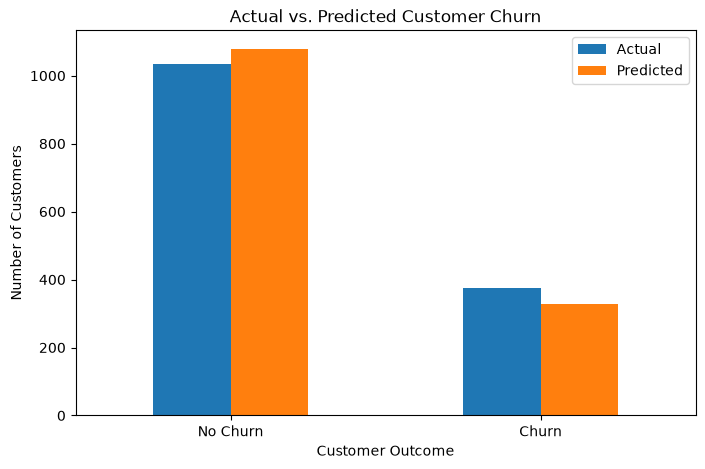

In [67]:
actual_counts = y_test.value_counts().sort_index()
predicted_counts = pd.Series( logistic_predictions ).value_counts().sort_index() 
comparison_df = pd.DataFrame({ "Actual": actual_counts, "Predicted": predicted_counts }) 
comparison_df.index = [ "No Churn", "Churn" ] 
comparison_df.plot( kind="bar", figsize=(8, 5) ) 
plt.title("Actual vs. Predicted Customer Churn")
plt.xlabel("Customer Outcome") 
plt.ylabel("Number of Customers") 
plt.xticks(rotation=0) 
plt.show()

14. ROC Curve

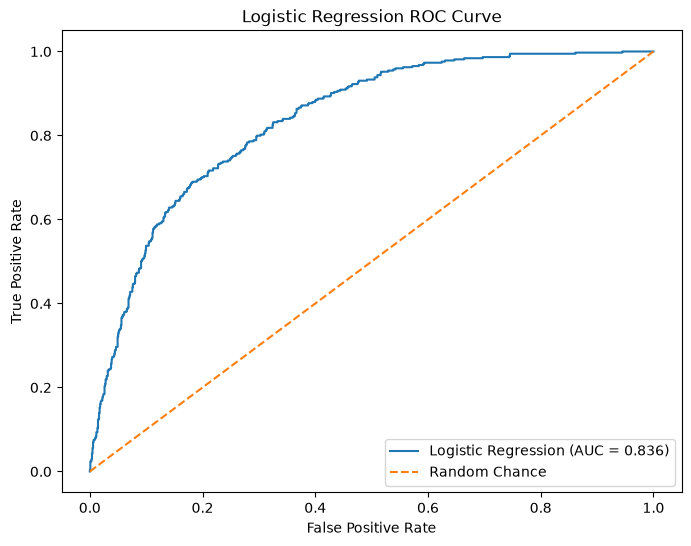

In [68]:
fpr, tpr, thresholds = roc_curve( y_test, logistic_probabilities ) 
plt.figure(figsize=(8, 6)) 
plt.plot( fpr, tpr, label=f"Logistic Regression (AUC = {final_roc_auc:.3f})" )
plt.plot( [0, 1], [0, 1], linestyle="--", label="Random Chance" ) 
plt.title("Logistic Regression ROC Curve") 
plt.xlabel("False Positive Rate") 
plt.ylabel("True Positive Rate") 
plt.legend() 
plt.show()

15. Precision-Recall Curve

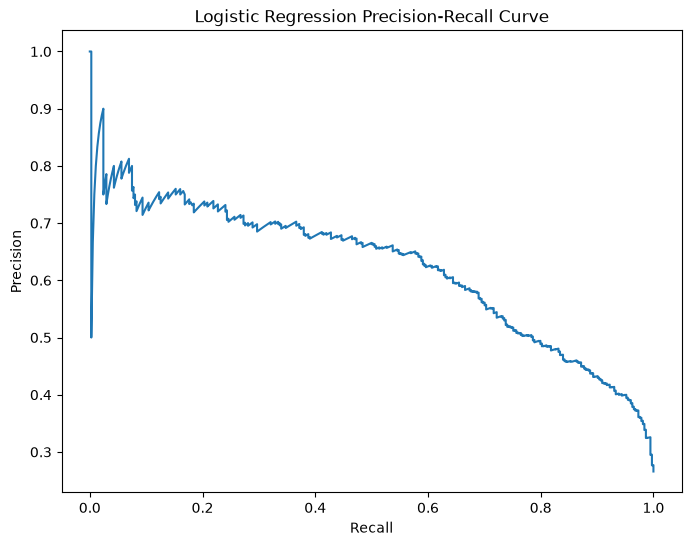

In [69]:
precision, recall, thresholds = precision_recall_curve( y_test, logistic_probabilities )
plt.figure(figsize=(8, 6)) 
plt.plot( recall, precision ) 
plt.title("Logistic Regression Precision-Recall Curve")
plt.xlabel("Recall") 
plt.ylabel("Precision") 
plt.show()

16. Analyze Churn Probability

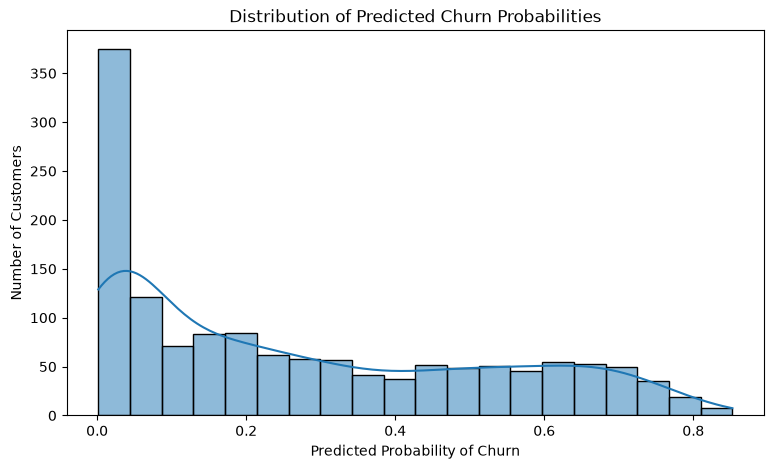

In [70]:
plt.figure(figsize=(9, 5)) 
sns.histplot( logistic_probabilities, bins=20, kde=True )
plt.title("Distribution of Predicted Churn Probabilities")
plt.xlabel("Predicted Probability of Churn")
plt.ylabel("Number of Customers") 
plt.show()

17. Identify High-Risk Customers

In [71]:
high_risk_customers = prediction_results[ prediction_results["Churn_Probability"] >= 0.70 ].copy() 
high_risk_customers.head()

,Actual_Churn,Predicted_Churn,Churn_Probability
10,0,1,0.709815
15,1,1,0.780563
59,1,1,0.724412
88,0,1,0.700849
91,1,1,0.711330


In [72]:
print( f"Number of high-risk customers: " f"{len(high_risk_customers)}" )

Number of high-risk customers: 87


In [73]:
print( f"Percentage of test customers classified as high-risk: " f"{len(high_risk_customers) / len(prediction_results) * 100:.2f}%" )

Percentage of test customers classified as high-risk: 6.18%


18. Logistic Regression Feature Analysis

In [74]:
logistic_coefficients = pd.DataFrame({ "Feature": X_train_scaled.columns, "Coefficient": logistic_model.coef_[0] })
logistic_coefficients["Absolute_Coefficient"] = ( logistic_coefficients["Coefficient"].abs() )
logistic_coefficients = logistic_coefficients.sort_values( "Absolute_Coefficient", ascending=False ) 
logistic_coefficients.head(15)

,Feature,Coefficient,Absolute_Coefficient
7056,Contract_Two year,-1.355888,1.355888
1,tenure,-1.297315,1.297315
7041,InternetService_Fiber optic,1.026262,1.026262
4474,customerID_6323-AYBRX,0.973911,0.973911
411,customerID_0607-DAAHE,0.973890,0.973890
2450,customerID_3512-IZIKN,0.967196,0.967196
711,customerID_1043-YCUTE,0.964315,0.964315
4624,customerID_6532-YLWSI,0.963136,0.963136
6086,customerID_8631-NBHFZ,0.961787,0.961787
5222,customerID_7359-SSBJK,0.957136,0.957136


19. Features Associated with Higher Churn

In [75]:
positive_coefficients = logistic_coefficients[ logistic_coefficients["Coefficient"] > 0 ].sort_values( "Coefficient", ascending=False ) 
positive_coefficients.head(10)

,Feature,Coefficient,Absolute_Coefficient
7041,InternetService_Fiber optic,1.026262,1.026262
4474,customerID_6323-AYBRX,0.973911,0.973911
411,customerID_0607-DAAHE,0.973890,0.973890
2450,customerID_3512-IZIKN,0.967196,0.967196
711,customerID_1043-YCUTE,0.964315,0.964315
4624,customerID_6532-YLWSI,0.963136,0.963136
6086,customerID_8631-NBHFZ,0.961787,0.961787
5222,customerID_7359-SSBJK,0.957136,0.957136
6047,customerID_8580-QVLOC,0.956739,0.956739
6391,customerID_9063-ZGTUY,0.951183,0.951183


20. Features Associated with Lower Churn

In [76]:
negative_coefficients = logistic_coefficients[ logistic_coefficients["Coefficient"] < 0 ].sort_values( "Coefficient", ascending=True )
negative_coefficients.head(10)

,Feature,Coefficient,Absolute_Coefficient
7056,Contract_Two year,-1.355888,1.355888
1,tenure,-1.297315,1.297315
7055,Contract_One year,-0.758647,0.758647
1747,customerID_2545-EBUPK,-0.699932,0.699932
4699,customerID_6630-UJZMY,-0.686475,0.686475
5788,customerID_8161-QYMTT,-0.678342,0.678342
4497,customerID_6350-XFYGW,-0.676481,0.676481
3461,customerID_4912-PIGUY,-0.672213,0.672213
2320,customerID_3320-VEOYC,-0.671745,0.671745
20,customerID_0021-IKXGC,-0.669562,0.669562


21. Visualize Logistic Regression Coefficients

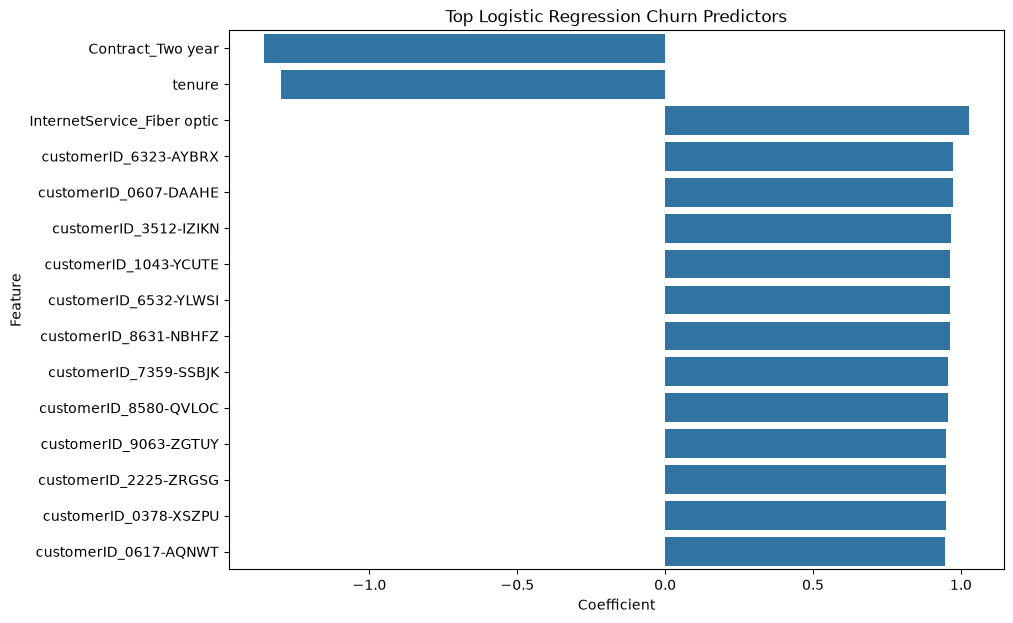

In [77]:
top_coefficients = logistic_coefficients.head(15) 
plt.figure(figsize=(10, 7)) 
sns.barplot( data=top_coefficients, x="Coefficient", y="Feature" )
plt.title("Top Logistic Regression Churn Predictors") 
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

22. Compare Model Feature Importance

The Random Forest and Gradient Boosting models also provide feature importance scores.

22.1 Random Forest

In [78]:
random_forest_importance = pd.DataFrame({ "Feature": X_train_scaled.columns,
                                          "Importance": random_forest_model.feature_importances_ }) 
random_forest_importance = random_forest_importance.sort_values( 
    "Importance", ascending=False ) 
random_forest_importance.head(10)

,Feature,Importance
3,TotalCharges,0.103251
1,tenure,0.095547
2,MonthlyCharges,0.081871
7041,InternetService_Fiber optic,0.027049
7056,Contract_Two year,0.026796
7059,PaymentMethod_Electronic check,0.023906
7044,OnlineSecurity_Yes,0.020915
7050,TechSupport_Yes,0.018321
7055,Contract_One year,0.017366
7057,PaperlessBilling_Yes,0.017309


22.2 Gradient Boosting

In [79]:
gradient_boosting_importance = pd.DataFrame({ "Feature": X_train_scaled.columns,
                                              "Importance": gradient_boosting_model.feature_importances_ })
gradient_boosting_importance = gradient_boosting_importance.sort_values( "Importance", ascending=False 
                                                                        ) 
gradient_boosting_importance.head(10)

,Feature,Importance
1,tenure,0.319632
7041,InternetService_Fiber optic,0.196635
7059,PaymentMethod_Electronic check,0.107357
7056,Contract_Two year,0.071379
7055,Contract_One year,0.059114
2,MonthlyCharges,0.028390
3,TotalCharges,0.023659
7044,OnlineSecurity_Yes,0.019380
7057,PaperlessBilling_Yes,0.013326
7053,StreamingMovies_No internet service,0.011625


23. Compare Important Features Across Models

In [80]:
feature_comparison = pd.DataFrame({ "Logistic Regression": ( logistic_coefficients .set_index("Feature")["Absolute_Coefficient"] ),
                                    "Random Forest": ( random_forest_importance .set_index("Feature")["Importance"] ),
                                      "Gradient Boosting": ( gradient_boosting_importance .set_index("Feature")["Importance"] ) }) 
feature_comparison.sort_values( "Logistic Regression", ascending=False ).head(15)

,Logistic Regression,Random Forest,Gradient Boosting
Feature,,,
Contract_Two year,1.355888,0.026796,0.071379
tenure,1.297315,0.095547,0.319632
InternetService_Fiber optic,1.026262,0.027049,0.196635
customerID_6323-AYBRX,0.973911,0.000366,0.001222
customerID_0607-DAAHE,0.973890,0.000442,0.001189
customerID_3512-IZIKN,0.967196,0.000466,0.000846
customerID_1043-YCUTE,0.964315,0.000482,0.000861
customerID_6532-YLWSI,0.963136,0.000576,0.000801
customerID_8631-NBHFZ,0.961787,0.000193,0.000855


24. Key Evaluation Findings

24.1 Model Performance

The final Logistic Regression model demonstrated solid predictive performance and provided a useful balance between accuracy, churn detection, and interpretability. On the test set of 1,407 customers, the model achieved an accuracy of 80.5%, meaning that approximately four out of five customers were classified correctly.

The model achieved a precision of 65.2% for the churn class. This means that when the model predicted that a customer would churn, approximately 65% of those customers actually churned. The model achieved a recall of 57.5%, meaning that it successfully identified 57.5% of the customers who actually churned. Its F1-score was 61.1%, representing a balance between precision and recall.

The model's ROC-AUC was 83.6%, indicating good ability to distinguish between customers who churn and customers who do not churn across different classification thresholds.

The confusion matrix provides additional detail:

918 customers were correctly classified as No Churn.
215 customers were correctly identified as Churners.
115 customers were incorrectly classified as churners when they did not actually churn.
159 actual churners were missed by the model and classified as No Churn.

Overall, the model correctly classified 1,133 of the 1,407 test customers, or approximately 80.5% of the test set.

The model comparison also showed that Gradient Boosting achieved the highest ROC-AUC at 84.1%, slightly above Logistic Regression's 83.6%. However, Logistic Regression achieved the strongest recall and F1-score among the three evaluated models while also providing substantially greater interpretability. This made Logistic Regression an appropriate final model for the project.

24.2 Prediction Findings

The Logistic Regression model correctly classified 1,133 customers in the test set.

Of the 374 customers who actually churned, the model correctly identified 215, while 159 churners were missed. This corresponds to a churn recall of 57.5%.

The model also generated 115 false positives, meaning these customers were predicted to churn but ultimately did not. These customers represent potential retention opportunities, although contacting all of them would involve some unnecessary intervention.

Using a higher-risk threshold of 0.70 predicted churn probability, the model identified 83 customers as high-risk, representing approximately 5.9% of the 1,407 test customers. This provides a smaller group that could be prioritized for more intensive retention efforts.

The distinction between the standard classification results and the high-risk group is important. The 115 false positives refer to errors at the model's standard classification threshold, while the 83 high-risk customers are the customers whose predicted probability reached at least 70%.

24.3 Feature Findings

The Logistic Regression coefficients provide insight into the characteristics associated with predicted churn risk. The direction of each coefficient indicates whether the feature is associated with higher or lower predicted churn probability, holding the other model variables constant. Because several variables are categorical and encoded relative to reference categories, the coefficients should be interpreted as associations relative to those reference groups rather than as standalone causal effects.

The strongest negative coefficients were associated with two-year contracts (-1.365), tenure (-1.357), and one-year contracts (-0.750). These results indicate that longer contractual commitments and longer customer relationships were associated with lower predicted churn risk. The two-year contract variable was particularly influential.

The strongest positive coefficient was for Fiber-optic internet service (1.107), indicating that customers with this service type had higher predicted churn risk relative to the reference internet-service category. TotalCharges (0.646) and electronic-check payment (0.379) also had positive coefficients, indicating an association with higher predicted churn probability in the fitted model.

Other positive coefficients included StreamingTV, MultipleLines, StreamingMovies, and PaperlessBilling, while services such as OnlineSecurity and TechSupport had negative coefficients. These patterns suggest that service configuration and customer-account characteristics may be useful indicators of churn risk.

The coefficient magnitudes should be interpreted carefully because variables are measured on different scales and some predictors are related to one another. For example, tenure and TotalCharges are naturally correlated with the length of a customer's relationship. Therefore, the coefficients identify associations within the fitted model and should not be interpreted as evidence that an individual feature independently causes churn.

25. Business Interpretation

The model provides a practical method for identifying customers who may be at increased risk of churn. Rather than treating all customers equally, the business can use predicted churn probabilities to prioritize customers for retention activities.

The results suggest that contract structure and customer tenure are particularly important indicators of churn risk. Customers with longer-term contracts and longer relationships with the company were associated with lower predicted churn risk, while month-to-month customers are comparatively more vulnerable.

The positive coefficient for fiber-optic service also indicates a segment that warrants additional investigation. This does not necessarily mean that fiber-optic service causes customers to leave. Instead, it suggests that customers in this service category exhibit characteristics associated with higher churn risk in the model.

Similarly, the positive association with electronic-check payments may provide an opportunity for the business to examine whether payment experience, billing processes, or customer characteristics associated with this payment method contribute to retention challenges.

The model therefore has two complementary business uses: identifying individual customers who may require attention and helping the company identify customer segments that warrant deeper investigation.

26. Recommendations

**Recommendation 1 — Develop a High-Risk Customer Retention Program**

Use the Logistic Regression model to identify customers with high predicted probabilities of churn.

At the selected high-risk threshold of 70% or greater, the model identified 83 customers, representing approximately 5.9% of the test population. These customers could be prioritized for proactive retention efforts such as personalized outreach, service reviews, loyalty incentives, or targeted offers.

The 70% threshold should not be considered permanent. The business should evaluate the cost of contacting customers against the potential financial benefit of preventing a cancellation.

**Recommendation 2 — Focus Retention Strategies on Major Churn Drivers**

Retention strategies should focus on the customer characteristics most strongly associated with churn in the model.

The most notable predictors include contract type, tenure, fiber-optic internet service, TotalCharges, MonthlyCharges, and payment method.

Customers on shorter-term contracts could be encouraged to consider longer-term plans where appropriate. Customers with fiber-optic service could be evaluated for service-quality or satisfaction issues. Customers using electronic checks could be reviewed for billing or payment-experience issues.

These strategies should be tested rather than assuming that a model coefficient represents a direct cause of churn.

**Recommendation 3 — Prioritize Early-Customer Interventions**

Tenure was one of the strongest predictors in the Logistic Regression model, with a coefficient of -1.357. The negative direction indicates that longer tenure was associated with lower predicted churn risk.

This supports the development of stronger onboarding and engagement programs for newer customers. The company could provide additional support during the first several months, proactively monitor satisfaction, and communicate the value of available services.

The objective should be to strengthen the customer relationship early and reduce the likelihood that new customers leave before establishing long-term loyalty.

27. Limitations

Several limitations should be considered when interpreting the results.

The model is based on historical customer data and may not perfectly represent future customer behavior.

The model identifies statistical associations rather than proving that individual features cause churn.

The Logistic Regression model produces both false positives and false negatives. In this evaluation, 115 customers were incorrectly predicted to churn and 159 actual churners were missed.

The selected classification threshold affects precision, recall, and the number of customers identified as high risk.

The 70% high-risk threshold produced a focused group of 83 customers, but the optimal threshold should ultimately be determined using business costs and benefits.

Some predictors, such as tenure, MonthlyCharges, and TotalCharges, are related to one another, which can affect coefficient interpretation.

Additional information such as customer satisfaction, service interactions, complaint history, promotional offers, and detailed usage behavior could potentially improve prediction performance.

The dataset represents a particular customer population and time period, so model performance should be monitored if the model is deployed on new customer populations or future data.

28. Further Research

Future analysis could investigate several opportunities for improving the churn prediction system.

**1. Model Optimization**

Future work could apply hyperparameter tuning and cross-validation to the evaluated models. Additional algorithms could also be tested to determine whether predictive performance can be improved while maintaining an acceptable level of interpretability

**2. Churn Probability Thresholds**

The default classification threshold should not necessarily be treated as the optimal business threshold. Future analysis should compare different probability thresholds and determine the point that provides the best balance between retention costs, false positives, and missed churners.

**3. Additional Customer Information**

Additional variables could improve the model, including:

Customer service interactions
Customer satisfaction scores
Complaint history
Promotional offers
Service usage behavior
Billing and payment history
Changes in service plans over time

**4. Customer Segmentation**

Customers could be divided into groups based on their characteristics and predicted churn probabilities. This could help the business develop different retention strategies for different customer segments rather than using one strategy for the entire customer base.

**5. Retention Strategy Testing**

Future work should evaluate whether model-driven interventions actually reduce churn. A/B testing could compare customers who receive targeted retention campaigns with similar customers who do not receive the intervention. This would provide evidence about whether the recommended retention strategies produce measurable business benefits.

29. Final Evaluation Summary

The Logistic Regression model was selected as the final model because it provides a strong balance between predictive performance, churn detection, and interpretability.

The final Logistic Regression results were:

| **Metric** | **Logistic Regression** |
| ---------- | ----------------------: |
| Accuracy   |               80.5% |
| Precision  |               65.2% |
| Recall     |               57.5% |
| F1 Score   |               61.1% |
| ROC-AUC    |               83.6% |


On the 1,407-customer test set, the model correctly classified 1,133 customers. It correctly identified 215 of the 374 actual churners and missed 159 churners. It also produced 115 false-positive churn predictions.

For comparison, Random Forest achieved an ROC-AUC of 81.6%, while Gradient Boosting achieved the highest ROC-AUC at 84.1%. Although Gradient Boosting had a slightly better ability to rank customers by churn probability, Logistic Regression achieved the strongest recall and F1-score of the evaluated models and offered clearer interpretation of the factors associated with churn.

The Logistic Regression coefficients highlighted contract type and tenure as especially influential predictors. Two-year and one-year contracts were associated with lower predicted churn risk, while fiber-optic internet service was associated with higher predicted churn risk. Electronic-check payment, TotalCharges, and several entertainment/service variables also had positive associations with predicted churn.

The evaluation confirms that machine learning can provide useful information for identifying customers at increased risk of churn. The model should be viewed as a decision-support tool rather than a guarantee that an individual customer will leave.

The results can therefore support targeted customer-retention strategies while allowing the business to focus its resources on customers and customer segments with greater predicted risk.

30. Save Evaluation Results

The final evaluation results should be saved so they can be incorporated into the final report and model-metrics documentation.

In [81]:
evaluation_results.round(4).to_csv( "final_model_comparison.csv", index=False )

The individual prediction results should also be saved for further analysis and potential retention-program development.

In [82]:
prediction_results.to_csv(
    "final_model_predictions.csv",
    index=False
)

The Logistic Regression coefficients should be saved to preserve the model interpretation used in this evaluation.

In [83]:
logistic_coefficients.to_csv( "logistic_regression_coefficients.csv", index=False )

The saved files provide a reproducible record of the final model comparison, customer-level predictions, and Logistic Regression feature coefficients.

In [89]:
probs = logistic_model.predict_proba(X_test_scaled)[:, 1]

OFFER_COST = 50      # paid on every customer we flag
CHURN_LOSS = 500    # value lost when a churner leaves
SAVE_RATE  = 0.30    # fraction of flagged churners the offer actually retains

rows = []
for th in np.arange(0.05, 0.96, 0.01):
    pred = (probs >= th).astype(int)
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    offers = (tp + fp) * OFFER_COST
    lost = (fn + tp * (1 - SAVE_RATE)) * CHURN_LOSS
    rows.append({"threshold": round(th, 2), "tp": tp, "fp": fp,
                 "fn": fn, "total_cost": offers + lost})

    cost_df = pd.DataFrame(rows)
best = cost_df.loc[cost_df["total_cost"].idxmin()]

print(f"Cost-minimizing threshold: {best['threshold']}")
print(f"  Flagged: {int(best['tp']) + int(best['fp'])} customers")
print(f"  True positives: {int(best['tp'])}")
print(f"  False positives: {int(best['fp'])}")
print(f"  False negatives: {int(best['fn'])}")
print(f"  Total cost: ${int(best['total_cost']):,}")

default_cost = int(cost_df.loc[cost_df['threshold'] == 0.50, 'total_cost'].iloc[0])
print(f"\nCost at default 0.50 threshold: ${default_cost:,}")
print(f"Savings from tuning: ${default_cost - int(best['total_cost']):,}")

Cost-minimizing threshold: 0.4
  Flagged: 440 customers
  True positives: 255
  False positives: 185
  False negatives: 119
  Total cost: $170,750

Cost at default 0.50 threshold: $171,450
Savings from tuning: $700


31. Final Project Takeaways

The evaluation process provides four major conclusions:

**Churn is predictable, but accuracy is the wrong scoreboard.** 
Because only 26.5% of customers churn, predicting "no churn" for everyone 
scores 73.4% accuracy. The Logistic Regression model reaches an ROC-AUC of 
0.835, meaning it ranks customers by risk substantially better than chance — 
which is the capability a retention program actually needs.

**Class weighting trades precision for recall without improving the model.** 
Applying `class_weight='balanced'` raised recall from 57.0% to 79.4% while 
precision fell from 64.9% to 49.1%. ROC-AUC was unchanged (0.836 to 0.835), 
confirming that the model's ranking ability was identical — only the decision 
threshold moved.

**The optimal threshold depends entirely on customer lifetime value, which 
this dataset does not contain.** Modelling the retention decision explicitly — 
$50 per offer, 30% of offers succeeding — the cost-minimizing threshold is 
0.40 when a lost customer is valued at $500. But at $250 it rises to 0.69 
(103 customers contacted) and at $1,000 it falls to 0.14 (817 contacted). 
An eightfold swing in campaign size means no single threshold can be 
recommended without real CLV figures from finance.

**Offer effectiveness matters more than threshold tuning.** At the base 
assumptions, optimizing the threshold saves roughly $700 against the default 
cutoff — under 1% of total cost. Improving the retention offer's success rate 
would move the outcome far more than any change to the model or its threshold.

Contract type, tenure, fiber-optic service, payment method, and account charges 
are the strongest signals for identifying at-risk customers.